<h1>Classical models in TSA</h1>

Import models and initialize parameters for usage across the notebook

In [94]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

from_date = '2011-1-1'
to_date = '2021-1-1'

Download META dataset from Yahoo Finance

In [95]:
quotes = yf.download('META', start=from_date , end=to_date)

[*********************100%***********************]  1 of 1 completed


In [96]:
print(f"First 10 rows of dataset:")
print(quotes.head(10))
quotes.describe()

First 10 rows of dataset:
                 Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2012-05-18  42.049999  45.000000  38.000000  38.230000  38.115242  573576400
2012-05-21  36.529999  36.660000  33.000000  34.029999  33.927845  168192700
2012-05-22  32.610001  33.590000  30.940001  31.000000  30.906942  101786600
2012-05-23  31.370001  32.500000  31.360001  32.000000  31.903942   73600000
2012-05-24  32.950001  33.209999  31.770000  33.029999  32.930851   50237200
2012-05-25  32.900002  32.950001  31.110001  31.910000  31.814211   37149800
2012-05-29  31.480000  31.690001  28.650000  28.840000  28.753426   78063400
2012-05-30  28.700001  29.549999  27.860001  28.190001  28.105379   57267900
2012-05-31  28.549999  29.670000  26.830000  29.600000  29.511147  111639200
2012-06-01  28.889999  29.150000  27.389999  27.719999  27.636787   41855500


,Open,High,Low,Close,Adj Close,Volume
count,2170.000000,2170.000000,2170.000000,2170.000000,2170.000000,2.170000e+03
mean,124.121313,125.563945,122.630866,124.157318,123.784617,3.213096e+07
std,68.074474,68.878920,67.270939,68.124602,67.920103,2.858937e+07
min,18.080000,18.270000,17.549999,17.730000,17.676777,5.913100e+06
25%,70.830000,71.552502,69.612501,70.849997,70.637312,1.619055e+07
50%,120.995003,122.009998,119.750000,120.820000,120.457314,2.327860e+07
75%,177.477501,179.022495,175.779995,177.470001,176.937271,3.773498e+07
max,300.160004,304.670013,293.049988,303.910004,302.997711,5.735764e+08


In [97]:
def custom_plot(y_original, model_fit, nsteps_forecast=100, last_samples_to_show=1000):
    
    y_original = y_original[-last_samples_to_show:] # List
    forecast = [np.nan] * len(y_original)
    fcast = model_fit.get_forecast(steps=nsteps_forecast).summary_frame()
    
    forecast.extend(fcast['mean'].tolist())
    
    lower = [np.nan] * len(y_original)
    lower.extend(fcast['mean_ci_lower'].tolist())
    upper = [np.nan] * len(y_original)
    upper.extend(fcast['mean_ci_upper'].tolist())

    y_original.extend([np.nan] * nsteps_forecast)

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(y_original, label='Data', color='blue')
    ax.plot(forecast,  label='Forecast', color='black', linestyle=':')
    ax.fill_between(range(len(y_original)), lower, upper, color='k', alpha=0.1)
    ax.legend()
    plt.show()

<h2>AR</h2>

Fit an AutoRegressive model with two lags

In [98]:
closes = quotes['Close'].values
train, test = closes[:-1], closes[-1]

model = SARIMAX(train, order = (2,0,0)) # AR(2)
model_fit_ar = model.fit()
model_fit_ar.summary()

/home/julian/miniconda3/envs/datascienceblog/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.08715D+03    |proj g|=  2.16786D+03

At iterate    5    f=  6.24185D+00    |proj g|=  7.92060D+00

At iterate   10    f=  2.96857D+00    |proj g|=  2.89007D-01

At iterate   15    f=  2.81279D+00    |proj g|=  1.77702D-02

At iterate   20    f=  2.55583D+00    |proj g|=  2.74179D-02

At iterate   25    f=  2.53519D+00    |proj g|=  3.00101D-03

At iterate   30    f=  2.53295D+00    |proj g|=  2.03867D-04

At iterate   35    f=  2.53270D+00    |proj g|=  1.34281D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2169
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -5493.410
Date:                Sat, 12 Oct 2024   AIC                          10992.820
Time:                        23:02:20   BIC                          11009.866
Sample:                             0   HQIC                         10999.053
                               - 2169                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9325      0.011     85.852      0.000       0.911       0.954
ar.L2          0.0674      0.011      6.192      0.000       0.046       0.089
sigma2         9.2417      0.077    119.801      0.000       9.091       9.393
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             59504.39
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):              15.88   Skew:                            -1.02
Prob(H) (two-sided):                  0.00   Kurtosis:                        28.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

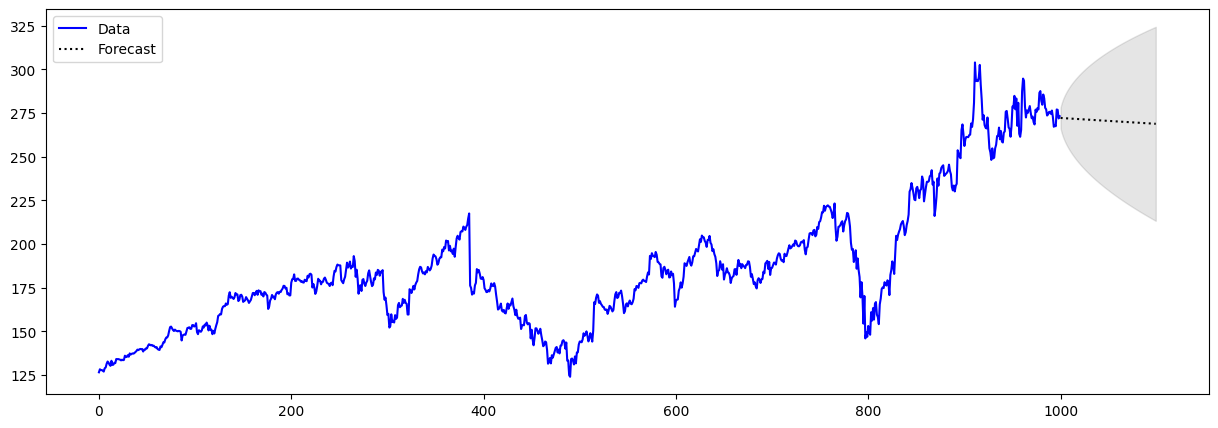

In [99]:
custom_plot(quotes['Close'].tolist(), model_fit_ar)

<h2>ARIMA</h2>

Download dataset from Yahoo Finance

In [32]:
quotes = yf.download('META', start = from_date, end = to_date)

[*********************100%***********************]  1 of 1 completed


In [77]:
closes = quotes['Close'].values
train, test = closes[:-1], closes[-1]

model = ARIMA(train, order = (5, 2, 3))
model_fit_arima = model.fit()
model_fit_arima.summary()

/home/julian/miniconda3/envs/datascienceblog/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2170
Model:                     AutoReg(2)   Log Likelihood               -5484.262
Method:               Conditional MLE   S.D. of innovations              3.036
Date:                Sat, 12 Oct 2024   AIC                          10976.523
Time:                        22:46:35   BIC                          10999.249
Sample:                             2   HQIC                         10984.834
                                 2170                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1402      0.136      1.033      0.301      -0.126       0.406
Close.L1       0.9309      0.021     43.467      0.000       0.889       0.973
Close.L2       0.0689      0.021      3.215      0.001       0.027       0.111
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.0002           +0.0000j            1.0002            0.0000
AR.2          -14.5100           +0.0000j           14.5100            0.5000
-----------------------------------------------------------------------------
"""

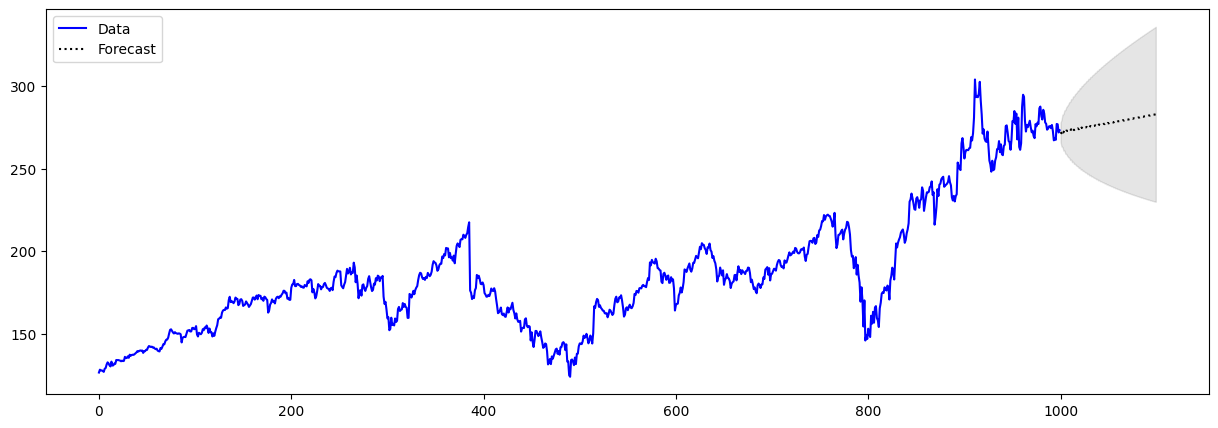

In [75]:
custom_plot(quotes['Close'].tolist(), model_fit_arima)

<h2>SARIMAX</h2>

In [92]:
closes = quotes['Close'].values
train, test = closes[:-1], closes[-1]

model = SARIMAX(train, order = (4, 2, 1), seasonal_order = (0, 0, 0, 0))
model_fit_sarimax = model.fit()
model_fit_sarimax.summary()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.60571D+00    |proj g|=  9.37092D-02

At iterate    5    f=  2.57375D+00    |proj g|=  9.88709D-02

At iterate   10    f=  2.53525D+00    |proj g|=  2.23952D-02

At iterate   15    f=  2.52720D+00    |proj g|=  6.88006D-03

At iterate   20    f=  2.52539D+00    |proj g|=  2.35469D-03

At iterate   25    f=  2.52527D+00    |proj g|=  8.86581D-04

At iterate   30    f=  2.52525D+00    |proj g|=  2.41005D-04

At iterate   35    f=  2.52525D+00    |proj g|=  1.06837D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2169
Model:               SARIMAX(4, 2, 1)   Log Likelihood               -5477.270
Date:                Sat, 12 Oct 2024   AIC                          10966.539
Time:                        22:55:51   BIC                          11000.626
Sample:                             0   HQIC                         10979.004
                               - 2169                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0643      0.012     -5.384      0.000      -0.088      -0.041
ar.L2          0.0108      0.012      0.887      0.375      -0.013       0.035
ar.L3         -0.0922      0.013     -7.236      0.000      -0.117      -0.067
ar.L4          0.0124      0.013      0.951      0.342      -0.013       0.038
ma.L1         -1.0000      0.057    -17.442      0.000      -1.112      -0.888
sigma2         9.1491      0.527     17.373      0.000       8.117      10.181
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             60140.86
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):              15.58   Skew:                            -1.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        28.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

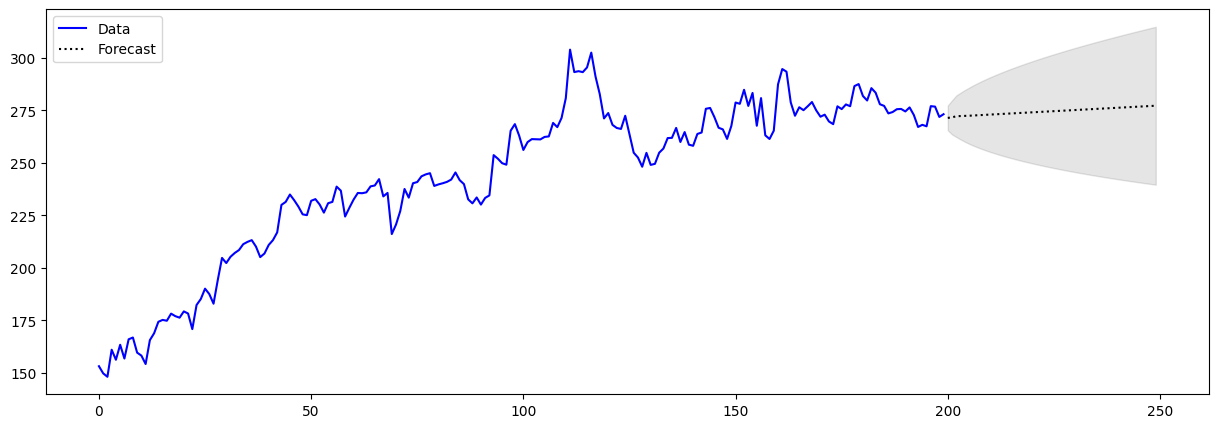

In [93]:
custom_plot(quotes['Close'].tolist(), model_fit_sarimax, nsteps_forecast=50, last_samples_to_show=200)